In [2]:
from functions import *
from operator import matmul
import pandas as pd
import numpy as np
from mass_charge_dict import ELEMENTS2Z, Z2ELEMENTS,elements_dict
from scipy import linalg
from scipy.spatial.transform import Rotation as rot_trafo
from math import log10 , floor
import glob as glob
import time as time
from scipy.stats import linregress 
import matplotlib.pyplot as plt
import os
import random as random

from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import  Matern ,RBF
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from ml_functions import *

#############################
#Init File Import for Information
#
 #+ glob.glob('tests/h2/H2_*/')# + glob.glob('tests/N2/N2_*/') + glob.glob('tests/O2/O2_*/') +glob.glob('tests/F2/F2_*/')

molecules = ['N2'] #['H2','N2','O2','F2','CO','HF']

X_df,y_df,col_name,Nat = gen_X_y_DF(molecules)

X_df = X_df.reset_index(drop = True)

y_df = y_df.reset_index(drop = True)

X_diag_prep, y_diag_prep, X_non_diag_prep, y_non_diag_prep = gen_feature_target_precursor(X_df,y_df)

grps_diag,grps_non_diag =  get_grps(X_diag_prep,X_non_diag_prep)

X_diag,y_diag =  transform_diag_prep(X_diag_prep,y_diag_prep)

X_non_diag,y_non_diag = transform_non_diag_prep(X_non_diag_prep,y_non_diag_prep)



In [5]:
import numpy as np
from operator import matmul
v = np.array([0,3,1])

R=  np.array([[1,0,0],
            [0,0,-1],
            [0,1,0]])

v =matmul(np.transpose(R),v)

v =matmul(R,v)

print(v)

[0 3 1]


In [3]:
gss = GroupShuffleSplit(n_splits=1,train_size=0.75,random_state = 42)

idx_diag = list(gss.split(X_diag, y_diag, grps_diag))

idx_non_diag = list(gss.split(X_non_diag,y_non_diag,grps_non_diag))

train_idx = idx_diag[0][0]
test_idx =  idx_diag[0][1]

X_train = X_diag[train_idx]
X_test = X_diag[test_idx]

y_train = y_diag[train_idx]
y_test = y_diag[test_idx]

train_idx_non_diag = idx_non_diag[0][0]
test_idx_non_diag =  idx_non_diag[0][1]

X_non_diag_train = X_non_diag[train_idx_non_diag]
X_non_diag_test = X_non_diag[test_idx_non_diag]

y_non_diag_train = y_non_diag[train_idx_non_diag]
y_non_diag_test = y_non_diag[test_idx_non_diag]


#############################
# Training and Prediction via ML
print('Start Fitting of Machine Learning')
regr_diag = RandomForestRegressor(n_estimators = 100,random_state=0,bootstrap=False)
#regr_diag = GaussianProcessRegressor(kernel = Matern() ,random_state=42)

regr_non_diag = RandomForestRegressor(n_estimators = 100,random_state=0, bootstrap=False)
#regr_non_diag = GaussianProcessRegressor(kernel = Matern(),random_state=42)

regr_diag.fit(X_train, y_train)
regr_non_diag.fit(X_non_diag_train, y_non_diag_train)

hess_diag_pred = regr_diag.predict(X_test)
hess_non_diag_pred = regr_non_diag.predict(X_non_diag_test)


Start Fitting of Machine Learning


Score of diag model: 0.2593298585695857
Score of non diag model: 0.43390945434013983


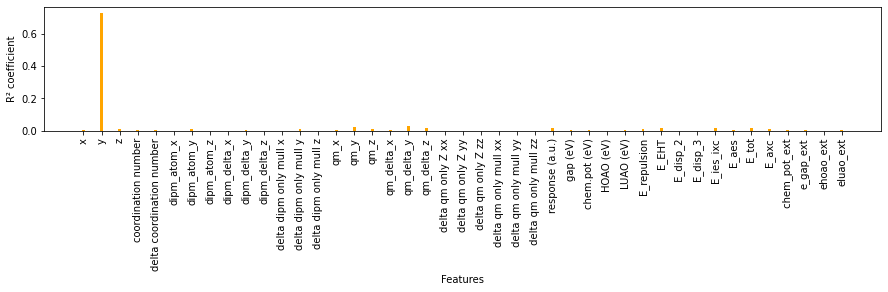

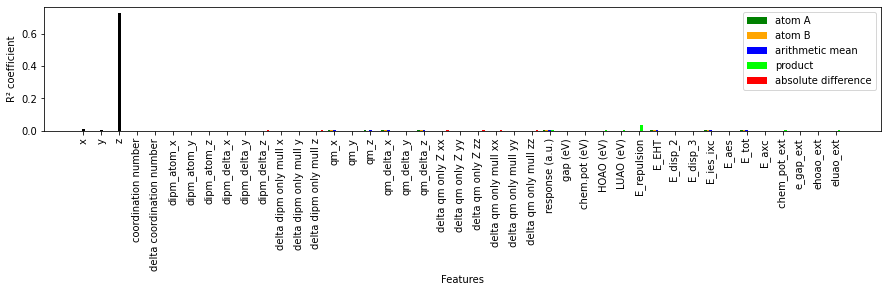

In [4]:

#############################
#Results and Plots of diagonal hessian matrix blocks

print('Score of diag model:',regr_diag.score(X_test,y_test))
importances = regr_diag.feature_importances_

ticks = np.array(range(len(X_diag[0])))

fig ,ax = plt.subplots()

ax.bar(ticks ,importances,alpha=1.0, width=0.15, color='orange')
ax.set_xlabel('Features')
ax.set_ylabel('R² coefficient')
ax.set_xticks(ticks)

ax.set_xticklabels(['x','y','z']+col_name,rotation=90)
plt.gcf().subplots_adjust(bottom=0.45)
fig.set_figwidth(15)

#plt.savefig('diag_r2_coefficents.png')
#plt.savefig('diag_r2_coefficents.svg')

np.array(range(int(max(grps_diag)+1)))

#############################
#Training and Prediction via ML


#############################
#Results and Plots of prediction of non diagonal hessian matrix blocks
print('Score of non diag model:',regr_non_diag.score(X_non_diag_test,y_non_diag_test))
importances = regr_non_diag.feature_importances_

ticks = np.array(range(43))

fig ,ax = plt.subplots()

ax.bar(ticks[:3] ,importances[:3],alpha=1.0, width=0.15, color='black')
ax.bar(ticks[3:]-0.3 ,importances[3:43],alpha=1.0, width=0.15, label = 'atom A',color='green')
ax.bar(ticks[3:]-0.15 ,importances[43:83],alpha=1.0, width=0.15, label = 'atom B',color='orange')
ax.bar(ticks[3:] ,importances[83:123],alpha=1.0, width=0.15, label = 'arithmetic mean',color='blue')
ax.bar(ticks[3:]+0.15 ,importances[123:163],alpha=1.0, width=0.15, label = 'product',color='lime')
ax.bar(ticks[3:]+0.3 ,importances[163:203],alpha=1.0, width=0.15, label = 'absolute difference',color='red')

ax.legend()
ax.set_xlabel('Features')
ax.set_ylabel('R² coefficient')
ax.set_xticks(ticks)
ax.set_xticklabels(['x','y','z'] + col_name,rotation=90)
plt.gcf().subplots_adjust(bottom=0.45)
fig.set_figwidth(15)
#plt.savefig('non_diag_r2_coefficents.png')
#plt.savefig('non_diag_r2_coefficents.svg')


In [50]:
def project_hess(hess_v,coord):
    idx = find_trans_rot(hess_v,coord)
    lamb,Q = linalg.eigh(hess_v)
    hess_projected_v = hess_v.copy()

    for i in idx:
        i = int(i)
        hess_projected_v -= lamb[i] * np.outer(Q.T[i], Q.T[i])

    return hess_projected_v

def find_trans_rot(hess,coord):

    Nat = len(coord)
    overlap_mat = np.zeros([3*Nat,6])

    trans_x = np.array([1.,0.,0.])
    trans_y = np.array([0.,1.,0.])
    trans_z = np.array([0.,0.,1.])

    for i in range(Nat):
        overlap_mat[0,3*i:3*i+3] = trans_x
        overlap_mat[1,3*i:3*i+3] = trans_y
        overlap_mat[2,3*i:3*i+3] = trans_z

        overlap_mat[3,3*i:3*i+3] = np.array([0.,coord.loc[i,'z'],-coord.loc[i,'y']])
        overlap_mat[4,3*i:3*i+3] = np.array([-coord.loc[i,'z'],0.,coord.loc[i,'x']])
        overlap_mat[5,3*i:3*i+3] = np.array([coord.loc[i,'y'],-coord.loc[i,'x'],0.])

    overlap_mat = overlap_mat / Nat
    overlap_mat = 1/(linalg.norm(overlap_mat,1)) * overlap_mat


    lamb, Q = linalg.eigh(hess)

    M = matmul(overlap_mat,Q)

    
    norm_x = np.array(linalg.norm(coord.loc[:,'x']))
    
    norm_y = np.array(linalg.norm(coord.loc[:,'y']))

    norm_z = np.array(linalg.norm(coord.loc[:,'z']))

    idx_len = 6 

    if (norm_x + norm_y) < 1e-6 or (norm_y + norm_z) < 1e-6 or (norm_z + norm_x)< 1e-6:
        idx_len = 5

    M_sum = np.zeros(3*Nat)
    for i in range(len(M_sum)):
        M_sum[i] = np.sum(np.abs(M[:,i]))

    idx_list = np.zeros(idx_len)
    for i in range(idx_len):
        idx = np.where(M_sum == np.amax(M_sum))[0][0]
        idx_list[i] = int(idx)
        M_sum[idx] -= M_sum[idx]

    return idx_list

#############################
#Transformation of the hessian blocks into a full hessian to compute the frequencies
rnd = random.randint(0,len(test_idx)-1)
rnd = 0

np.savetxt('grps',grps_diag)
id = grps_diag[test_idx[rnd]]*2

#np.array(X_diag_prep.loc[id,['molecule','variation']])

mol = 0#int(X_diag_prep.loc[id,['molecule']])
file_num =12 #int(X_diag_prep.loc[id,['variation']])

print('Molecule:',mol, 'and its variation:',file_num)

hess_diag = np.zeros([3,3])
hess_non_diag = np.zeros([3,3])

file_path = glob.glob(f'tests/{molecules[mol]}/{molecules[mol]}_*/')
init_path_coord = f'{file_path[file_num]}'+'/init_coord/coord.xyz'
coord,head = import_coord(init_path_coord)

path_00 = glob.glob(f'{file_path[file_num]}'+'apf_coord/atoms_0_0*/')
path_01 = glob.glob(f'{file_path[file_num]}'+'apf_coord/atoms_0_1*/')

R_00 = np.genfromtxt(path_00[0]+'R_inert_apf.txt')
R_01 = np.genfromtxt(path_01[0]+'R_inert_apf.txt')

k= int((rnd+1)//18*18)
for i in range(3):
    for j in range(3):
        hess_diag[i,j] = hess_diag_pred[k]
        hess_non_diag[i,j] = hess_non_diag_pred[k]
        k += 1

hess = np.zeros([6,6])

hess[0:3,0:3] = matmul(matmul(np.transpose(R_00),hess_diag),(R_00))
hess[3:6,3:6] = matmul(matmul(np.transpose(R_00),hess_diag),(R_00))

hess[0:3,3:6] = matmul(matmul(np.transpose(R_01),hess_non_diag),(R_01))
hess[3:6,0:3] = matmul(matmul(np.transpose(R_01),hess_non_diag),(R_01))

np.savetxt('hess_pred.txt',hess)


hess_diag_test = import_hess(path_00[0]+'/hessian',coord)[0:3,0:3]
hess_non_diag_test = import_hess(path_01[0]+'/hessian',coord)[0:3,3:6]

hess_test = np.zeros([6,6])

hess_test[0:3,0:3] = matmul(matmul(np.transpose(R_00),hess_diag_test),(R_00))
hess_test[3:6,3:6] = matmul(matmul(np.transpose(R_00),hess_diag_test),(R_00))

hess_test[0:3,3:6] = matmul(matmul(np.transpose(R_01),hess_non_diag_test),(R_01))
hess_test[3:6,0:3] = matmul(matmul(np.transpose(R_01),hess_non_diag_test),(R_01))



hess_mass = mass_weighted_hessian(hess.copy(),coord['atoms'])
freq_mass = freq(hess_mass)

#print(freq_mass)

hess_proj = project_hess(hess.copy(),coord)
hess_proj_mass = mass_weighted_hessian(hess_proj.copy(),coord['atoms'])
freq_mass_proj = freq(hess_proj_mass)

#print(freq_mass_proj)


hess_test_mass = mass_weighted_hessian(hess_test.copy(),coord['atoms'])
freq_test_mass = freq(hess_test_mass)


#print(freq_test_mass)

hess_test_proj = project_hess(hess_test.copy(),coord)
hess_test_proj_mass = mass_weighted_hessian(hess_test_proj.copy(),coord['atoms'])
freq_test_mass_proj = freq(hess_test_proj_mass)

print(freq_test_mass_proj)


Molecule: 0 and its variation: 12
[6.66921658e+02 1.27751268e-05 9.71101918e-06 8.25883661e-06
 3.27468956e-06 1.17089206e-05]


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import r_regression
length = 1000
feature1 = np.linspace(0,10,length)
feature2 = np.linspace(0,10,length)**2
feature3 = np.exp(np.linspace(0,10,length))
feature4 = np.linspace(0,10,length)**5


feature = np.array([feature1,feature2,feature3,feature4]).T

target = np.linspace(0,10,length)
for i in range(len(target)):
    if i%2 == 0:
        target[i] = 0

print(r_regression(feature,target))



[0.44855403 0.43471686 0.31322643 0.36951643]


In [4]:
import numpy as np
from operator import matmul

#-0.23333973	0	0.11666986	0	0	0.11666987

def rot_Z(alpha):
     R = np.array([[np.cos(alpha), -np.sin(alpha), 0],
                   [np.sin(alpha),  np.cos(alpha), 0],
                   [0,          0,                 1]])
     return R


qm_atom_xx =-0.23333973
qm_atom_xy = 0
qm_atom_yy = 0.11666986
qm_atom_xz = 0
qm_atom_yz = 0
qm_atom_zz = 0.11666987



qm = np.array([[qm_atom_xx,qm_atom_xy,qm_atom_xz],
               [qm_atom_xy,qm_atom_yy,qm_atom_yz],
               [qm_atom_xz,qm_atom_yz,qm_atom_zz]])

print(qm)

rotM = rot_Z(np.pi/4)


qm_rot = matmul(matmul(rotM,qm),np.transpose(rotM))

print(qm_rot)

[[-0.23333973  0.          0.        ]
 [ 0.          0.11666986  0.        ]
 [ 0.          0.          0.11666987]]
[[-0.05833494 -0.1750048   0.        ]
 [-0.1750048  -0.05833493  0.        ]
 [ 0.          0.          0.11666987]]


0.2291820702889583 0.1746964715231335
0.24327740464082165 0.19204690377566658
0.2973150100885874 0.24036217110857427
0.29673462711572773 0.25459634763171834


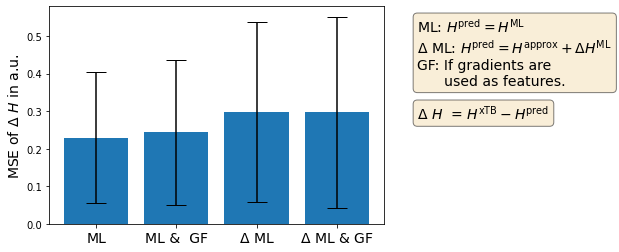

In [6]:
import numpy as np
import matplotlib.pyplot as plt

MSE0 = np.genfromtxt('MSE_list.txt')
MSE1 = np.genfromtxt('MSE_list_gradFeature.txt')
MSE2 = np.genfromtxt('MSE_list_delta.txt')
MSE3 = np.genfromtxt('MSE_list_delta_gradFeature.txt')

print(np.mean(MSE0),np.std(MSE0))
print(np.mean(MSE1),np.std(MSE1))
print(np.mean(MSE2),np.std(MSE2))
print(np.mean(MSE3),np.std(MSE3))
Names = [r'ML',r'ML &  GF',r'$\Delta$ ML',r'$\Delta$ ML & GF']
MSE_mean = [np.mean(MSE0),np.mean(MSE1),np.mean(MSE2),np.mean(MSE3)]
MSE_std = [np.std(MSE0),np.std(MSE1),np.std(MSE2),np.std(MSE3)]
fig,ax  = plt.subplots()
ax.bar([1,2,3,4],MSE_mean,yerr=MSE_std,capsize=10)
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(Names,fontsize=14)
textstr = r'ML: $H^\mathrm{pred} =  H^\mathrm{ML}$' + '\n' +  r'$\Delta$ ML: $H^\mathrm{pred} = H^\mathrm{approx} + \Delta H^\mathrm{ML}  $'+ '\nGF: If gradients are \n      used as features.'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(1.1, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
textstr = r'$\Delta$ $H$  = $H^\mathrm{xTB} - H^\mathrm{pred}$'
ax.text(1.1, 0.55, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
plt.ylabel(r'MSE of $\Delta$ $H$ in a.u.', fontsize =14)
plt.savefig('MSE_DifferentModels.png', bbox_inches='tight')

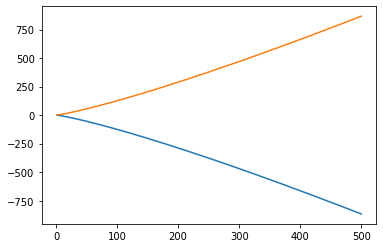

In [32]:
x = np.linspace(1,500,1000)

y = -0.5*x+0.5

y1 = 0.5*x**1.2 + 0.5
y = 1 - y1
plt.plot(x,y)
plt.plot(x,y1)
#plt.xscale('log')
